In [76]:
# Importing the dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [77]:
# Data loading and understanding
data = pd.read_csv('../dataset/churn_data.csv')
data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
data.shape

(7043, 21)

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [80]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [81]:
# Dropping the 'customerID' column as it is not useful for prediction
data.drop('customerID', axis=1, inplace=True)

In [82]:
data.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [83]:
# Understing the unique calues in each column

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for column in data.columns:
    if column not in numerical_columns:
        print(f"{column}: {data[column].unique()}")
        print("\n")

gender: ['Female' 'Male']


SeniorCitizen: [0 1]


Partner: ['Yes' 'No']


Dependents: ['No' 'Yes']


PhoneService: ['No' 'Yes']


MultipleLines: ['No phone service' 'No' 'Yes']


InternetService: ['DSL' 'Fiber optic' 'No']


OnlineSecurity: ['No' 'Yes' 'No internet service']


OnlineBackup: ['Yes' 'No' 'No internet service']


DeviceProtection: ['No' 'Yes' 'No internet service']


TechSupport: ['No' 'Yes' 'No internet service']


StreamingTV: ['No' 'Yes' 'No internet service']


StreamingMovies: ['No' 'Yes' 'No internet service']


Contract: ['Month-to-month' 'One year' 'Two year']


PaperlessBilling: ['Yes' 'No']


PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Churn: ['No' 'Yes']




In [84]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [85]:
# Converting 'TotalCharges' to float, coercing errors to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [86]:
data['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [88]:
print(data['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


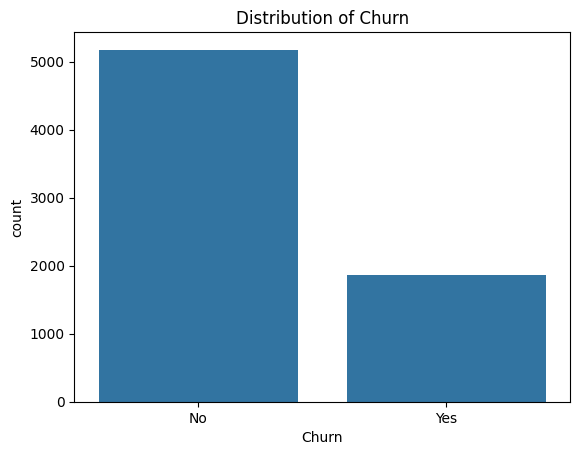

In [89]:
# Understanding the target variable distribution
sns.countplot(x='Churn', data=data)
plt.title('Distribution of Churn')
plt.show()

**Insights:**

1) Removed User_ID
2) No missing values
3) Class imbalance identified in the target var.

In [90]:
# 3. Exploratory Data Analysis (EDA)
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


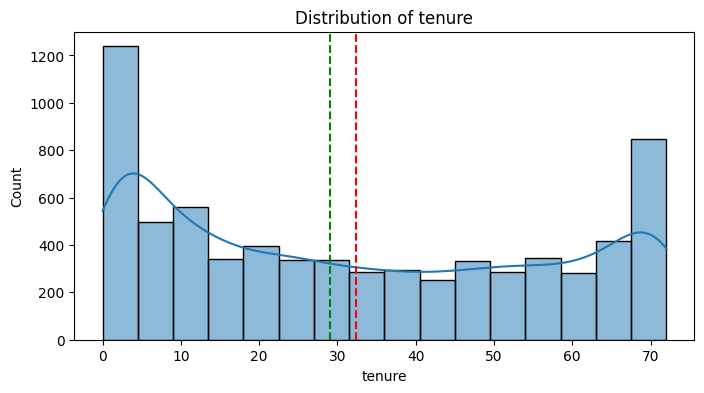

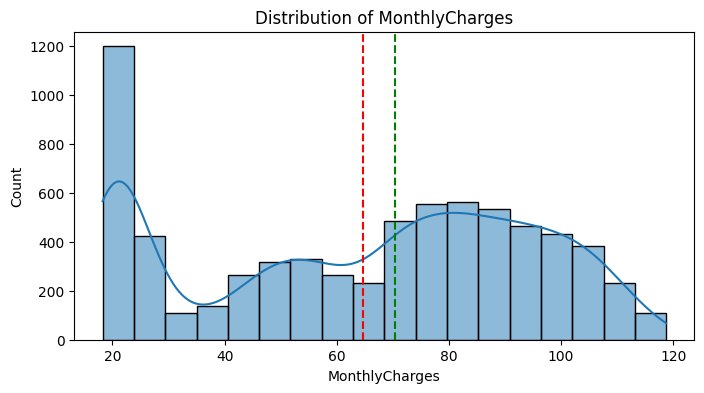

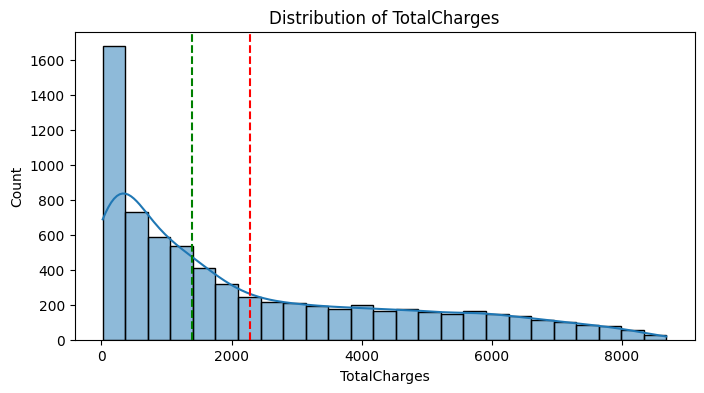

In [91]:
# Skewed data check visualization
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[column], kde=True)
    plt.axvline(data[column].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(data[column].median(), color='green', linestyle='--', label='Median')
    plt.title(f'Distribution of {column}')
    plt.show()


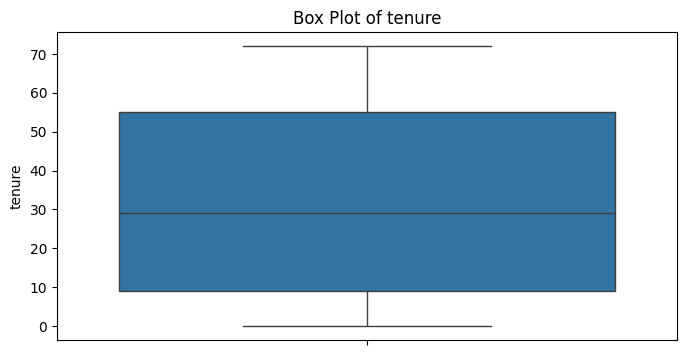

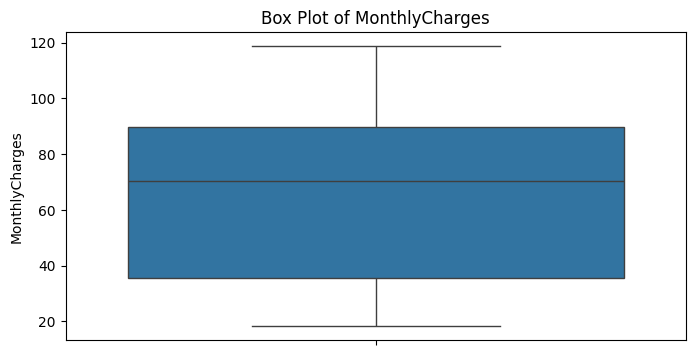

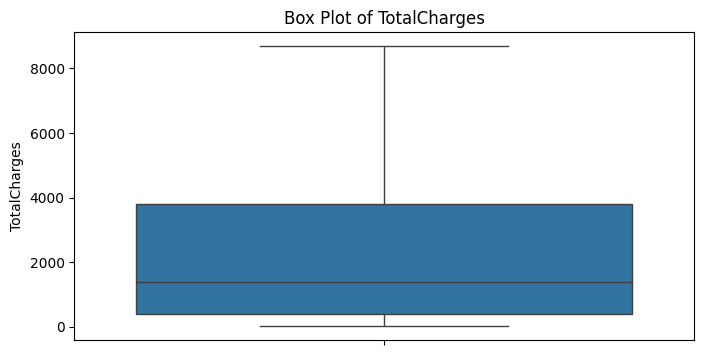

In [92]:
# Box plots for outlier detection
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

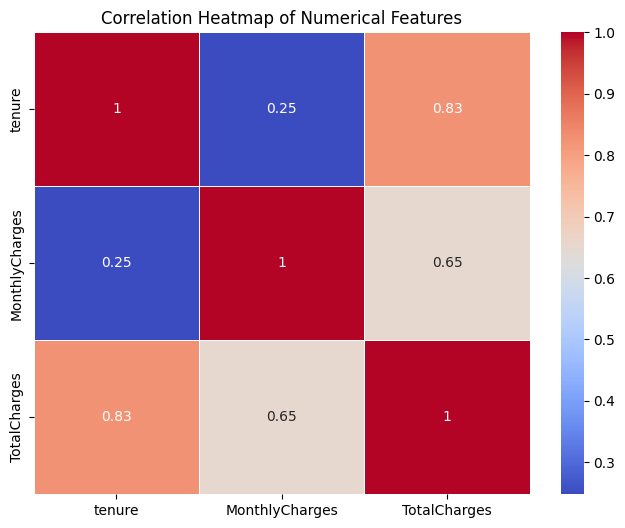

In [93]:
# Correlation heatmap for numerical features to check multicollinearity
plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


In [94]:
# Analysis of categorical features
object_columns = data.select_dtypes(include=['object']).columns.tolist()
object_columns = ['SeniorCitizen'] + object_columns  # Adding 'SeniorCitizen' to the list of categorical columns
object_columns


['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

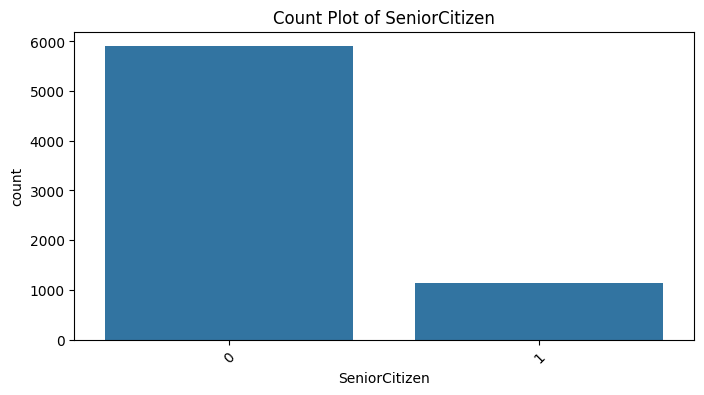

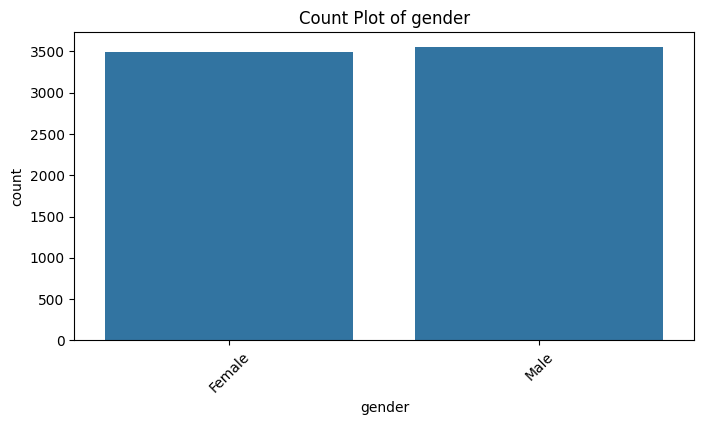

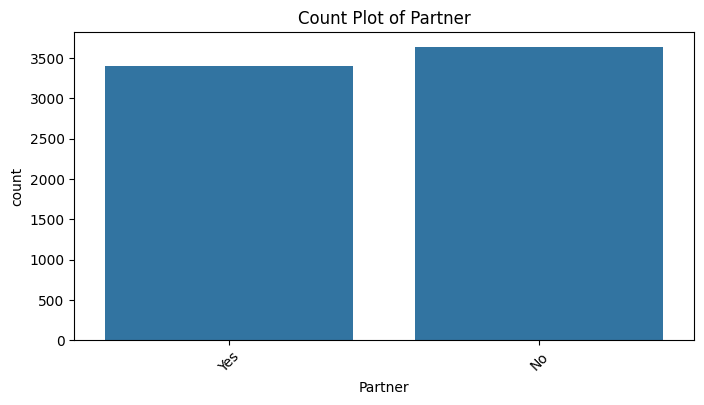

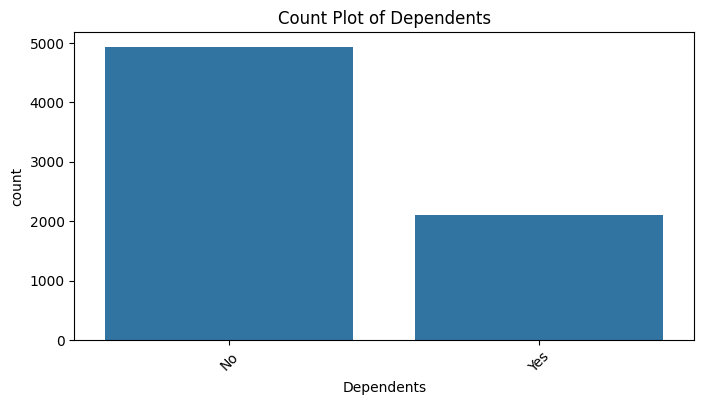

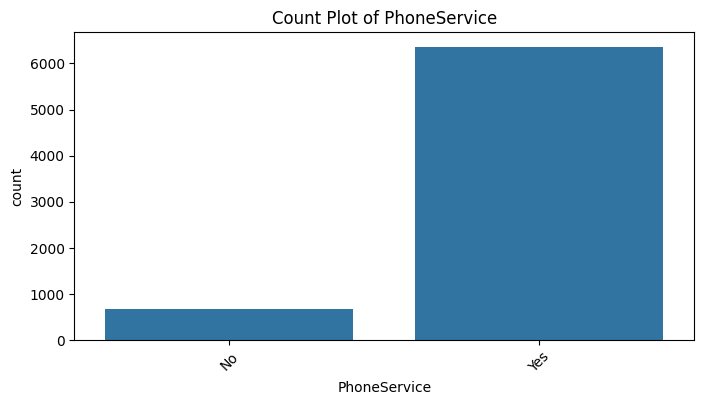

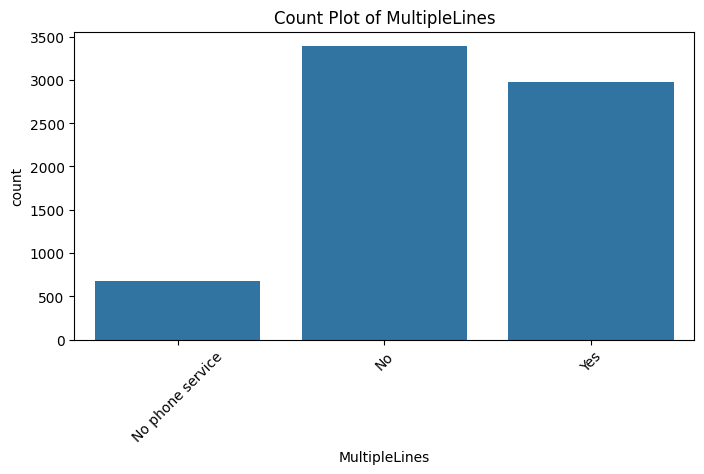

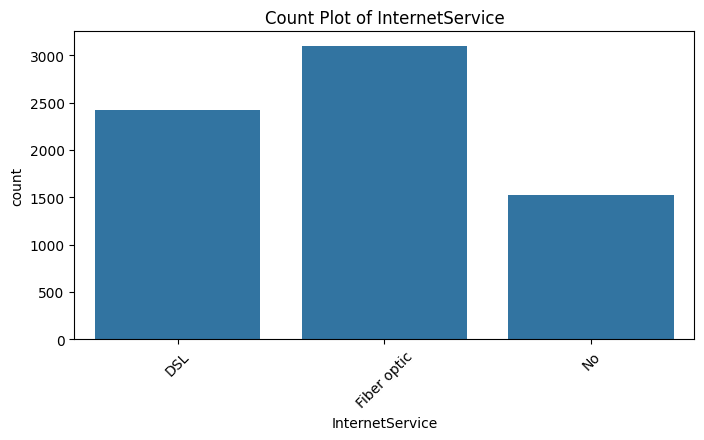

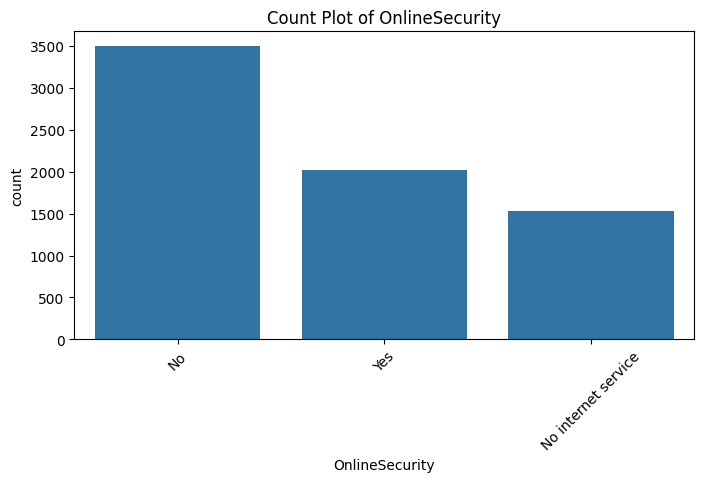

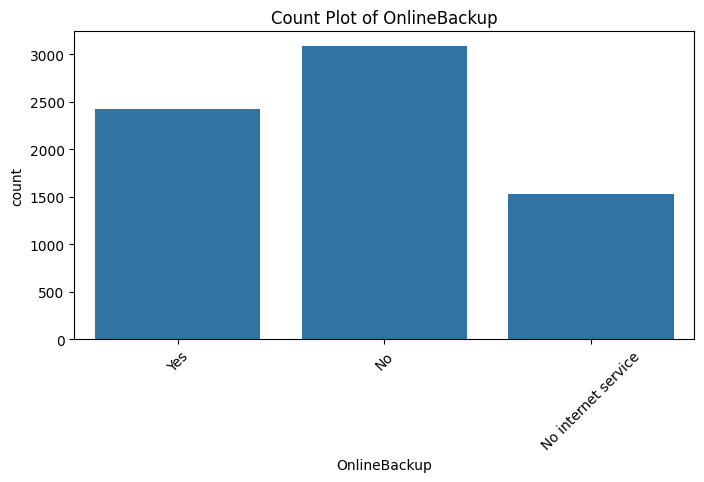

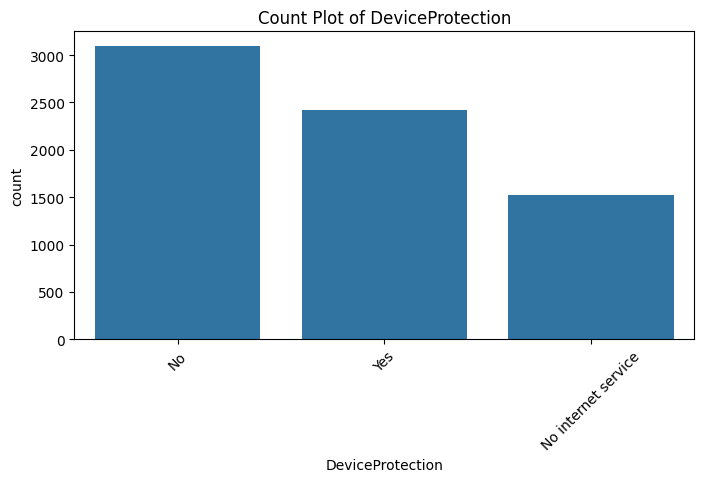

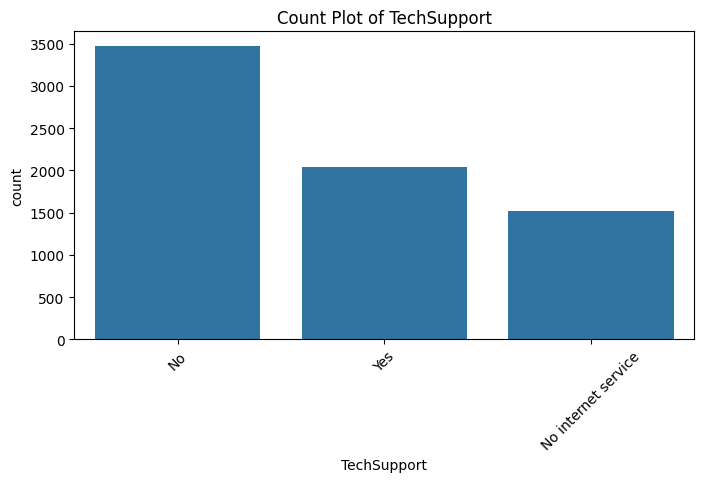

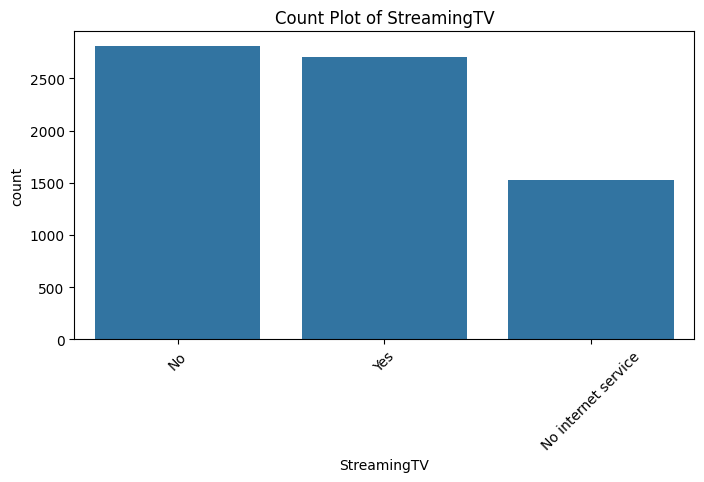

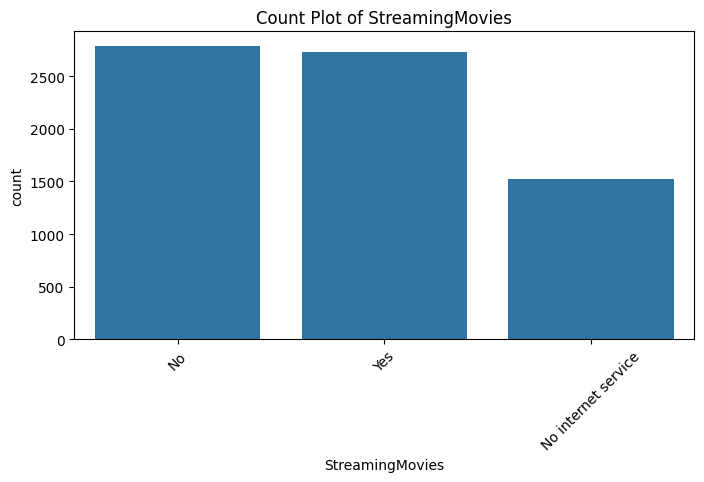

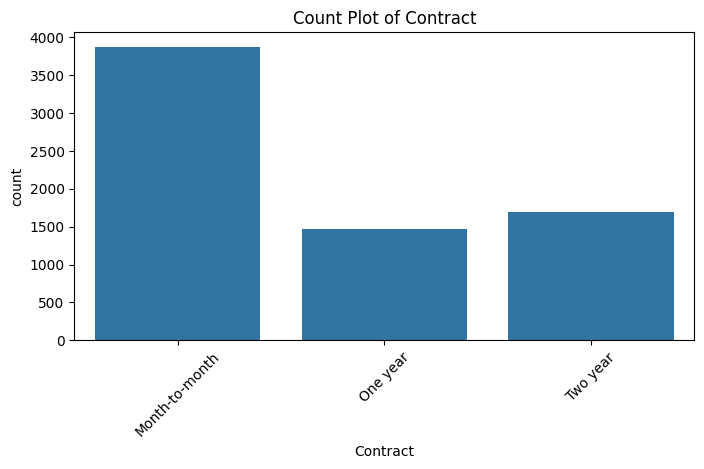

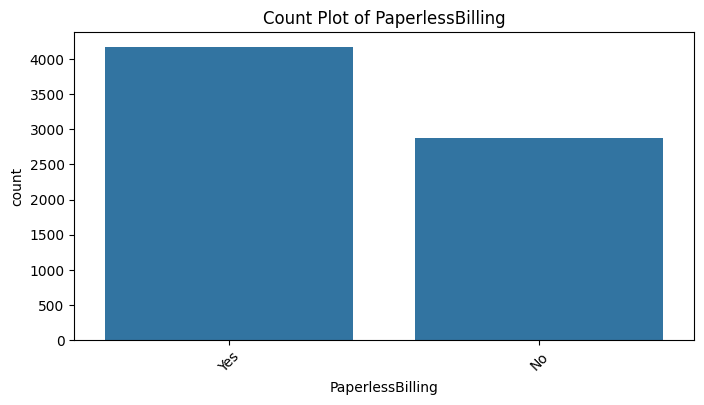

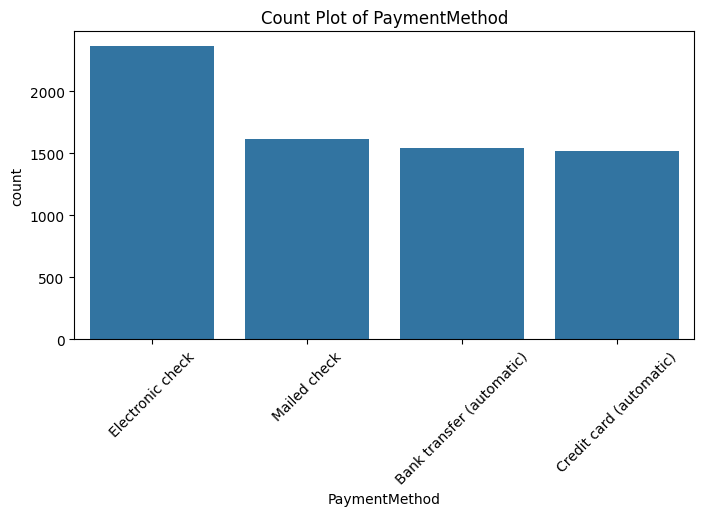

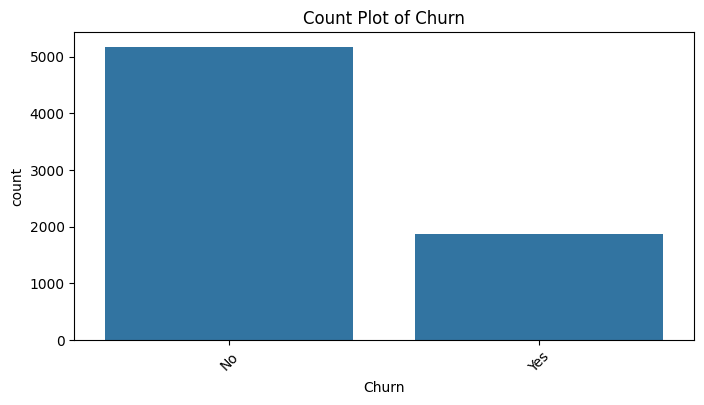

In [95]:
for column in object_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=data[column])
    plt.title(f'Count Plot of {column}')
    plt.xticks(rotation=45)
    plt.show()

In [96]:
# 4. Data Preprocessing
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Label encoding of target column

In [97]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

In [98]:
data['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [99]:
# Label encoding for categorical features
encoders = {}

for column in object_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    encoders[column] = le

# Save encoders
with open('../exports/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

In [100]:
encoders

{'SeniorCitizen': LabelEncoder(),
 'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [101]:
print(encoders['gender'].classes_)

['Female' 'Male']


In [102]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [103]:
# Handle missing values in TotalCharges
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# Verify no NaN values remain
print("Missing values in data:")
print(data.isnull().sum())


Missing values in data:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


C:\Users\SOHAN\AppData\Local\Temp\ipykernel_17776\3027493362.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [104]:
# 5. Training and Test Data Split
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [106]:
# Using SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [107]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


In [108]:
# 5. Model Building (Training with default hyperparameters)
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}


In [109]:
# Dictonary to store cross validation scores
cv_scores = {}

# Performing 5 - cross validation for each model
for model_name, model in models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
    cv_scores[model_name] = scores
    print(f"{model_name} Cross-Validation Accuracy: {np.mean(scores):.4f}")
    print("="*70)


Decision Tree Cross-Validation Accuracy: 0.7803
Random Forest Cross-Validation Accuracy: 0.8402


c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:25] WARNING: C:\actio

XGBoost Cross-Validation Accuracy: 0.8311


c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [110]:
cv_scores

{'Decision Tree': array([0.68115942, 0.71722054, 0.81752266, 0.84229607, 0.84350453]),
 'Random Forest': array([0.73248792, 0.77039275, 0.90332326, 0.89546828, 0.89909366]),
 'XGBoost': array([0.71799517, 0.74622356, 0.90332326, 0.88761329, 0.90030211])}

In [111]:
# 5.1 Random Forest Hyperparameter Tuning (since it gave higher accuracy compared to other models using default hyperparameters)
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
# 5.2 Model Evaluation
y_pred = rf_model.predict(X_test)


In [113]:
print("Accuracy_score:", accuracy_score(y_test, y_pred))
print("\n\nConfusion_matrix:", confusion_matrix(y_test, y_pred))
print("\n\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy_score: 0.7806955287437899


Confusion_matrix: [[885 151]
 [158 215]]


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.59      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [114]:
# Increasing the accuracy by tuning the hyperparameters of the Random Forest model
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=10,
                                        min_samples_split=5, min_samples_leaf=2, random_state=42)

rf_model_tuned.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
# Testing the tuned model
y_pred_tuned = rf_model_tuned.predict(X_test)
print("Accuracy_score:", accuracy_score(y_test, y_pred_tuned))
print("\n\nConfusion_matrix:", confusion_matrix(y_test, y_pred_tuned))
print("\n\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Accuracy_score: 0.7771469127040455


Confusion_matrix: [[833 203]
 [111 262]]


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      1036
           1       0.56      0.70      0.63       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [116]:
# 5.3 Still, the accuracy is not good. So, we can try other models like XGBoost and tune their hyperparameters to see if we can get better results.
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)


c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [117]:
# Testing the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

In [118]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\n\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7806955287437899


Confusion Matrix:
 [[885 151]
 [158 215]]


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.59      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [119]:
# Hyperparameter tuning for XGBoost
xgb_model_tuned = XGBClassifier(n_estimators=200, max_depth=10
                                    , learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_model_tuned.fit(X_train_smote, y_train_smote)

c:\Users\SOHAN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [120]:
# Testing the tuned model
y_pred_tuned = rf_model_tuned.predict(X_test)
print("Accuracy_score:", accuracy_score(y_test, y_pred_tuned))
print("\n\nConfusion_matrix:", confusion_matrix(y_test, y_pred_tuned))
print("\n\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Accuracy_score: 0.7771469127040455


Confusion_matrix: [[833 203]
 [111 262]]


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      1036
           1       0.56      0.70      0.63       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



# Comparing the tuned RFC and XGB Models, RFC is giving better results than XGB. So, we can use the tuned RFC model for deployment.
# Though there is still imbalance in the data, we can try other techniques like ensemble methods, or we can try to collect more data to improve the model performance.
# As of now, we can use the tuned RFC model for deployment.

Text(0.5, 1.0, 'XGBoost Cross-Validation Accuracy')

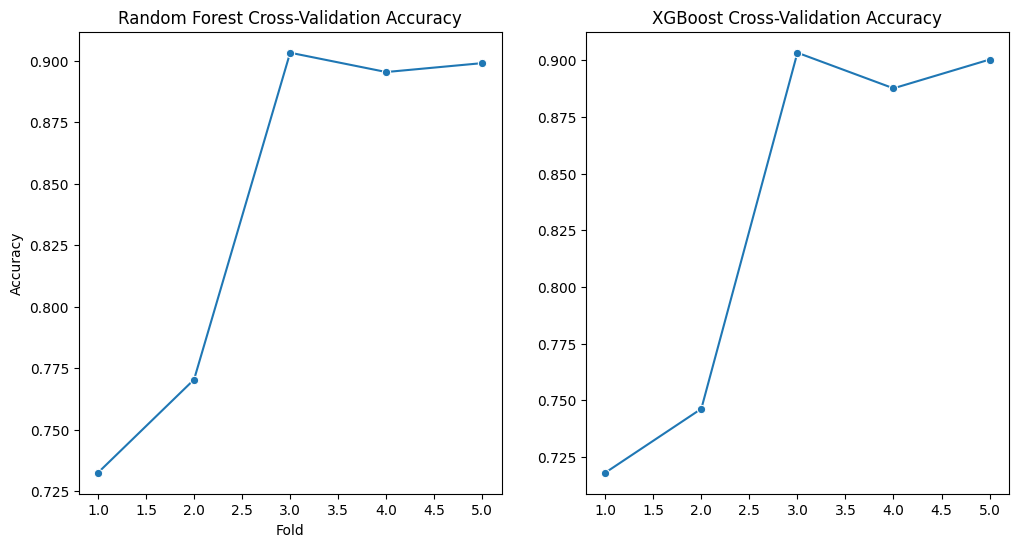

In [121]:
# 6. Data Visualization and Interpretation of Results

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the curves during training for Random Forest and XGBoost models to see if there is any overfitting or underfitting. We can plot the learning curves for both models.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.lineplot(x=range(1, 6), y=cv_scores['Random Forest'], marker='o')
plt.title('Random Forest Cross-Validation Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.subplot(1, 2, 2)
sns.lineplot(x=range(1, 6), y=cv_scores['XGBoost'], marker='o')
plt.title('XGBoost Cross-Validation Accuracy')


In [122]:
# 7. Saving the model for deployment
with open('../exports/customer_churn_model.pkl', 'wb') as f:
    pickle.dump(rf_model_tuned, f)


In [123]:
# 7. Load the saved model and encoders to make predictions on new data
with open('../exports/customer_churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('../exports/encoders.pkl', 'rb') as f:
    loaded_encoders = pickle.load(f)

In [124]:
for column in data.columns:
    features_column = data.columns.tolist()


In [125]:
print(features_column)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [126]:
input_data = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "Yes",
    "tenure": 71,
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "Yes",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Two year",
    "PaperlessBilling": "No",
    "PaymentMethod": "Bank transfer (automatic)",
    "MonthlyCharges": 106.7,
    "TotalCharges": 7382.25
}

input_data_df = pd.DataFrame([input_data])

# Load encoders
with open('../exports/encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

print("Original input data:")
input_data_df.head()

# Apply encoding - only for columns that exist in input_data
for column, encoder in encoders.items():
    if column in input_data_df.columns:
        input_data_df[column] = encoder.transform(input_data_df[column])

print("\nEncoded input:")
input_data_df.head()

Original input data:

Encoded input:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,1,71,1,2,1,2,0,2,0,2,2,2,0,0,106.7,7382.25


In [127]:
# Making the prediction using the loaded model
prediction = loaded_model.predict(input_data_df)
predict_proba = loaded_model.predict_proba(input_data_df)

print(prediction)

# Results
print(f"Predicted class: {'Churn' if prediction[0] == 1 else 'Not Churn'}")
print(f"Prediction probabilities: {predict_proba[0]}")


[0]
Predicted class: Not Churn
Prediction probabilities: [0.83781679 0.16218321]
